# Single Case Attribution Analysis

This notebook provides detailed attribution analysis for a single case:

1. **Input**: Case name/ID + prefix length + attribution target
2. **Output**: Full attribution matrix for every suffix prediction step
3. **Visualization**: Interactive navigation through suffix steps

Use this notebook to understand how the model makes predictions for individual cases.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.bpic17_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: BPIC17


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

## 2. Select Case for Analysis

In [4]:
# List available cases
case_names = list(eval_helper.cases.keys())
print(f"Sample cases: {case_names[:10]}")
print(f"Total cases: {len(case_names)}")

Sample cases: ['Application_1000086665', 'Application_1000806256', 'Application_1001114274', 'Application_1001866944', 'Application_1002013470', 'Application_1002032547', 'Application_1002348901', 'Application_1002442935', 'Application_1002485344', 'Application_100305707']
Total cases: 6301


In [14]:
# ============================================================
# CONFIGURATION - Set your case and prefix length here
# ============================================================
CASE_NAME = "Application_1001866944"  # Change this to analyze a specific case
PREFIX_LENGTH = 1          # Change this to set prefix length
TARGET = CONFIG.concept_name  # Usually 'Activity'

print(f"Analyzing: {CASE_NAME}, prefix_len={PREFIX_LENGTH}, target={TARGET}")

Analyzing: Application_1001866944, prefix_len=1, target=concept:name


In [15]:
# Get case data
def get_case_data(case_name, prefix_len, eval_helper):
    """Get prefix and suffix data for a case."""
    if case_name not in eval_helper.cases:
        raise ValueError(f"Case {case_name} not found")
    
    full_case = eval_helper.cases[case_name]
    
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix, suffix
    
    raise ValueError(f"Prefix length {prefix_len} not found for case {case_name}")

prefix, suffix = get_case_data(CASE_NAME, PREFIX_LENGTH, eval_helper)
print(f"Got prefix with {PREFIX_LENGTH} events")

Got prefix with 1 events


## 3. Compute Attribution for Each Suffix Step

In [16]:
def compute_suffix_step_attributions(tool, prefix, prefix_len, target, n_steps=50, max_suffix_steps=10):
    """
    Compute attribution maps for each step of suffix prediction.
    
    Returns:
        List of (suffix_step, attribution_map, predicted_activity) tuples
    """
    # Convert prefix format
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results = []
    
    for suffix_step in range(max_suffix_steps):
        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target=target,
                target_class='auto',  # Use predicted class
                suffix_scope='step',
                suffix_step=suffix_step,
                method='integrated_gradients',
                n_steps=n_steps
            )
            
            # Check if EOS was predicted (end of suffix)
            if 'EOS' in attr_map.target_description or 'END' in attr_map.target_description:
                results.append((suffix_step, attr_map, 'EOS'))
                break
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
        except Exception as e:
            print(f"Stopped at suffix step {suffix_step}: {e}")
            break
    
    return results

print("Computing attributions for each suffix step...")
suffix_attributions = compute_suffix_step_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, 
    n_steps=CONFIG.ig_steps,
    max_suffix_steps=10
)
print(f"Computed attributions for {len(suffix_attributions)} suffix steps")

Computing attributions for each suffix step...
Stopped at suffix step 4: index 4 is out of bounds for dimension 0 with size 4
Computed attributions for 4 suffix steps


## 4. Visualize Attribution Matrix per Suffix Step

In [17]:
def plot_attribution_heatmap(attr_map, title_prefix="", figsize=(14, 8)):
    """
    Plot attribution matrix as a heatmap.
    """
    # Build matrix from attributions
    matrix = attr_map.to_numpy()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Disable grid (can cause artifacts with heatmaps)
    ax.grid(False)
    
    # Use diverging colormap centered at 0
    vmax = np.abs(matrix).max()
    if vmax == 0:
        vmax = 1
    
    # Use interpolation='nearest' to prevent artifacts between cells
    im = ax.imshow(matrix, cmap='RdBu_r', aspect='auto', 
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    
    # Labels
    ax.set_yticks(range(len(attr_map.feature_names)))
    ax.set_yticklabels(attr_map.feature_names)
    ax.set_xticks(range(len(attr_map.step_labels)))
    ax.set_xticklabels(attr_map.step_labels, rotation=45, ha='right')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attribution Score')
    
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Features')
    ax.set_title(f"{title_prefix}{attr_map.target_description}")
    
    # Add value annotations for smaller matrices
    if matrix.shape[0] * matrix.shape[1] <= 50:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       color=color, fontsize=11)
    
    plt.tight_layout()
    return fig

In [18]:
# Display attribution for each suffix step
for suffix_step, attr_map, pred in suffix_attributions:
    print(f"\n{'='*80}")
    print(f"SUFFIX STEP {suffix_step}: {pred}")
        
    # Also print text version
    print(attr_map.to_string())


SUFFIX STEP 0: concept:name = W_Handle leads (class 24) [integrated_gradients]
ATTRIBUTION MAP: concept:name = W_Handle leads (class 24) [integrated_gradients]
Prefix length: 1 | Suffix scope: step
Convergence delta: 0.001172

                      enc(A_Crea..    dec(SOS)
----------------------------------------------
        concept:name |      0.0211      0.4755
              Action |      0.0143      0.0000
        org:resource |      0.0115      0.9426
         EventOrigin |      0.0011      0.0000
lifecycle:transition |      0.0115      0.6233
       case:LoanGoal |      0.0027      0.0000
case:ApplicationType |      0.0117      0.0000
            Accepted |      0.0021      0.0000
            Selected |      0.0040      0.0000
   case_elapsed_time |      0.0136      0.1295
  event_elapsed_time |      0.0000      0.0000
         day_in_week |      0.0005      0.0000
      seconds_in_day |      0.0001      0.0000
case:RequestedAmount |      0.0004      0.0000
FirstWithdrawalAmo..

## 5. Interactive Suffix Step Navigator

In [23]:
# Interactive widget to navigate through suffix steps
if len(suffix_attributions) > 0:
    @interact(step=widgets.IntSlider(min=0, max=len(suffix_attributions)-1, value=0, description='Suffix Step'))
    def show_step(step):
        suffix_step, attr_map, pred = suffix_attributions[step]
        
        print(f"Suffix Step {suffix_step}: Predicting {pred}")
        print(f"Convergence delta: {attr_map.convergence_delta:.6f}" if attr_map.convergence_delta else "")
        
        fig = plot_attribution_heatmap(attr_map, f"Step {suffix_step}: ")
        plt.show()
else:
    print("No suffix attributions computed.")

interactive(children=(IntSlider(value=0, description='Suffix Step', max=3), Output()), _dom_classes=('widget-i…

## 6. Feature Importance Across Suffix Steps

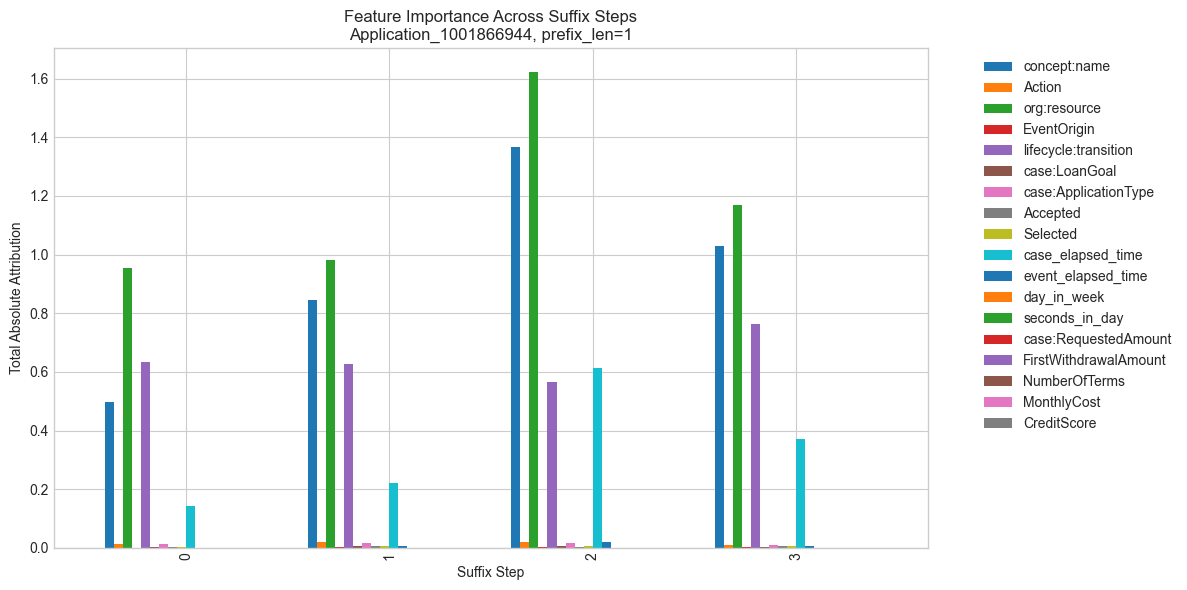


Feature importance by suffix step:


,concept:name,Action,org:resource,EventOrigin,lifecycle:transition,case:LoanGoal,case:ApplicationType,Accepted,Selected,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,CreditScore
Suffix Step,,,,,,,,,,,,,,,,,,
0,0.496635,0.014332,0.954057,0.001053,0.634733,0.002740,0.011723,0.002065,0.003970,0.143028,0.000000,0.000541,0.000129,0.000445,0.0,0.0,0.0,0.0
1,0.843999,0.020733,0.981953,0.002694,0.627131,0.005014,0.016450,0.005034,0.007493,0.220698,0.004728,0.000878,0.000004,0.000475,0.0,0.0,0.0,0.0
2,1.367663,0.020692,1.623864,0.002219,0.565824,0.005098,0.015885,0.004050,0.006634,0.612440,0.018736,0.000914,0.000204,0.000416,0.0,0.0,0.0,0.0
3,1.030223,0.010928,1.167568,0.002231,0.762021,0.004065,0.009014,0.004728,0.005226,0.371954,0.006354,0.000199,0.000350,0.000047,0.0,0.0,0.0,0.0


In [20]:
# Aggregate feature importance across all suffix steps
if suffix_attributions:
    feature_importance_by_step = {}
    
    for suffix_step, attr_map, pred in suffix_attributions:
        feature_importance_by_step[suffix_step] = {}
        
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_importance_by_step[suffix_step][feat] = np.abs(vals).sum()
    
    # Create DataFrame
    importance_df = pd.DataFrame(feature_importance_by_step).T
    importance_df.index.name = 'Suffix Step'
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    importance_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Suffix Step')
    ax.set_ylabel('Total Absolute Attribution')
    ax.set_title(f'Feature Importance Across Suffix Steps\n{CASE_NAME}, prefix_len={PREFIX_LENGTH}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    print("\nFeature importance by suffix step:")
    display(importance_df)

## 7. Encoder vs Decoder Split

Encoder vs Decoder Attribution Split:
  Encoder: 62.4% (total: 9.0437)
  Decoder SOS: 37.6% (total: 5.4448)


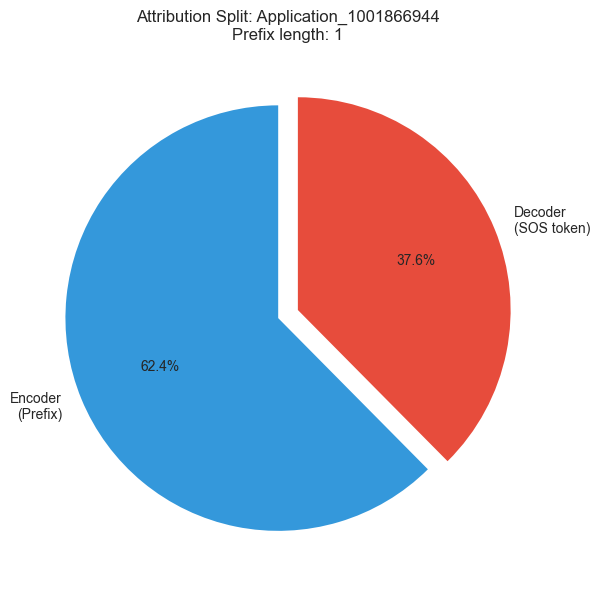

In [21]:
# Compute encoder vs decoder split for first suffix step
if suffix_attributions:
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    actual_len, prefix_for_split = tool.extract_prefix_from_process(process, PREFIX_LENGTH)
    
    split = tool.compute_encoder_decoder_attribution_split(
        prefix=prefix_for_split,
        target_output=TARGET,
        target_value='auto',
        suffix_step=0,
        n_steps=CONFIG.ig_steps
    )
    
    print(f"Encoder vs Decoder Attribution Split:")
    print(f"  Encoder: {split['encoder_fraction']*100:.1f}% (total: {split['encoder_total']:.4f})")
    print(f"  Decoder SOS: {split['decoder_sos_fraction']*100:.1f}% (total: {split['decoder_sos_total']:.4f})")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(8, 6))
    labels = ['Encoder\n(Prefix)', 'Decoder\n(SOS token)']
    sizes = [split['encoder_fraction'], split['decoder_sos_fraction']]
    colors = ['#3498db', '#e74c3c']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=90, explode=(0.05, 0.05))
    ax.set_title(f'Attribution Split: {CASE_NAME}\nPrefix length: {PREFIX_LENGTH}')
    plt.tight_layout()
    plt.show()

## 8. Summary

In [22]:
print("="*80)
print(f"SUMMARY: Single Case Attribution Analysis")
print("="*80)
print(f"\nCase: {CASE_NAME}")
print(f"Prefix length: {PREFIX_LENGTH}")
print(f"Target: {TARGET}")
print(f"\nSuffix predictions:")
for step, attr_map, pred in suffix_attributions:
    print(f"  Step {step}: {pred}")

if suffix_attributions:
    print(f"\nTop features (first suffix step):")
    first_attr = suffix_attributions[0][1]
    feature_totals = {}
    for feat in first_attr.feature_names:
        if feat in first_attr.attributions:
            vals = first_attr.attributions[feat]
            if hasattr(vals, 'detach'):
                vals = vals.detach().cpu().numpy()
            feature_totals[feat] = np.abs(vals).sum()
    
    for feat, val in sorted(feature_totals.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {feat}: {val:.4f}")

SUMMARY: Single Case Attribution Analysis

Case: Application_1001866944
Prefix length: 1
Target: concept:name

Suffix predictions:
  Step 0: concept:name = W_Handle leads (class 24) [integrated_gradients]
  Step 1: concept:name = W_Handle leads (class 24) [integrated_gradients]
  Step 2: concept:name = W_Handle leads (class 24) [integrated_gradients]
  Step 3: concept:name = W_Complete application (class 23) [integrated_gradients]

Top features (first suffix step):
  org:resource: 0.9541
  lifecycle:transition: 0.6347
  concept:name: 0.4966
  case_elapsed_time: 0.1430
  Action: 0.0143
